In [5]:
# =====================================================
# TASK 4 - GEOSPATIAL DATA ANALYSIS
# Phase 1 - Import Libraries & Setup
# =====================================================

import pandas as pd
import numpy as np
import random
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
!pip install folium


   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   -------------------- ------------------- 1/2 [folium]
   ---------------------------------------- 2/2 [folium]



In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import folium
from folium.plugins import HeatMap, MarkerCluster

warnings.filterwarnings("ignore")

In [7]:
# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [8]:
# Random Seed
random.seed(42)
np.random.seed(42)

In [9]:
print("="*60)
print("TASK 4 - GEOSPATIAL DATA ANALYSIS")
print("="*60)

print("\nLibraries Loaded Successfully")

print("\nVersions")
print("Pandas :", pd.__version__)
print("NumPy  :", np.__version__)

print("\nEnvironment Ready...")

TASK 4 - GEOSPATIAL DATA ANALYSIS

Libraries Loaded Successfully

Versions
Pandas : 2.3.3
NumPy  : 2.3.5

Environment Ready...


In [15]:
# =====================================================
# Phase 2 - Generate Advanced Dataset
# =====================================================

cities = [

("Chennai",13.0827,80.2707),
("Coimbatore",11.0168,76.9558),
("Madurai",9.9252,78.1198),
("Salem",11.6643,78.1460),
("Trichy",10.7905,78.7047),
("Erode",11.3410,77.7172),
("Tirunelveli",8.7139,77.7567),
("Vellore",12.9165,79.1325),
("Thoothukudi",8.7642,78.1348),
("Nagercoil",8.1780,77.4344),
("Karur",10.9601,78.0766),
("Namakkal",11.2189,78.1674),
("Dindigul",10.3673,77.9803),
("Kanchipuram",12.8342,79.7036),
("Cuddalore",11.7480,79.7714),
("Thanjavur",10.7867,79.1378),
("Hosur",12.7409,77.8253),
("Pollachi",10.6583,77.0080),
("Sivakasi",9.4493,77.7970),
("Ooty",11.4064,76.6932)

]

sales_data = []

for i in range(1000):

    city = random.choice(cities)

    city_name = city[0]
    lat = city[1] + np.random.uniform(-0.04,0.04)
    lon = city[2] + np.random.uniform(-0.04,0.04)

    population = random.randint(80000,3000000)

    customers = random.randint(100,5000)

    sales = random.randint(50000,500000)

    competitors = random.randint(1,20)

    demand = round(random.uniform(40,100),2)

    avg_income = random.randint(18000,90000)

    existing_store = random.choice(["Yes","No"])

    sales_data.append([

        city_name,
        lat,
        lon,
        population,
        customers,
        sales,
        competitors,
        demand,
        avg_income,
        existing_store

    ])

columns=[

"City",
"Latitude",
"Longitude",
"Population",
"Customers",
"Sales",
"Competitors",
"Demand_Index",
"Average_Income",
"Existing_Store"

]

df = pd.DataFrame(sales_data,columns=columns)

# -----------------------------------------------------
# Create Customer Dataset
# -----------------------------------------------------

customer_data=[]

for i in range(5000):

    customer_data.append([

        i+1,

        random.choice(df["City"]),

        random.randint(18,65),

        random.choice(["Male","Female"]),

        random.randint(500,30000),

        random.randint(1,20),

        random.choice(["Silver","Gold","Premium"])

    ])

customer_df=pd.DataFrame(customer_data,columns=[

"Customer_ID",
"City",
"Age",
"Gender",
"Purchase_Amount",
"Purchase_Frequency",
"Customer_Segment"

])

# -----------------------------------------------------
# Store Dataset
# -----------------------------------------------------

store=[]

for i in range(300):

    city=random.choice(cities)

    store.append([

        i+1,

        city[0],

        city[1]+np.random.uniform(-0.03,0.03),

        city[2]+np.random.uniform(-0.03,0.03),

        random.randint(200000,900000),

        random.randint(5,40),

        random.randint(2010,2026)

    ])

store_df=pd.DataFrame(store,columns=[

"Store_ID",
"City",
"Latitude",
"Longitude",
"Revenue",
"Employees",
"Opening_Year"

])

# -----------------------------------------------------
# Population Dataset
# -----------------------------------------------------

population=[]

for city in cities:

    population.append([

        city[0],

        random.randint(100000,5000000),

        round(random.uniform(0.5,5.5),2),

        round(random.uniform(45,98),2)

    ])

population_df=pd.DataFrame(population,columns=[

"City",
"Population",
"Growth_Rate",
"Urban_Percentage"

])

# -----------------------------------------------------
# Save CSV Files
# -----------------------------------------------------

df.to_csv("sales_locations.csv",index=False)

customer_df.to_csv("customer_data.csv",index=False)

store_df.to_csv("store_data.csv",index=False)

population_df.to_csv("population_data.csv",index=False)

print("="*60)
print("DATASETS GENERATED SUCCESSFULLY")
print("="*60)

print("\nSales Dataset Shape :",df.shape)
print("Customer Dataset Shape :",customer_df.shape)
print("Store Dataset Shape :",store_df.shape)
print("Population Dataset Shape :",population_df.shape)



DATASETS GENERATED SUCCESSFULLY

Sales Dataset Shape : (1000, 10)
Customer Dataset Shape : (5000, 7)
Store Dataset Shape : (300, 7)
Population Dataset Shape : (20, 4)


In [17]:
print("\nSales Dataset")
display(df.head())

print("\nCustomer Dataset")
display(customer_df.head())


Sales Dataset


,City,Latitude,Longitude,Population,Customers,Sales,Competitors,Demand_Index,Average_Income,Existing_Store
0,Erode,11.316891,77.739871,2209218,4596,87866,12,87.17,41723,Yes
1,Hosur,12.773640,77.814919,2540000,3001,122714,4,90.68,69442,Yes
2,Salem,11.684402,78.177760,742375,3516,368388,14,49.97,23962,No
3,Coimbatore,11.044490,76.930425,2081632,1967,423531,5,56.71,26304,Yes
4,Ooty,11.442903,76.683334,1318772,2054,78404,8,89.10,40120,No



Customer Dataset


,Customer_ID,City,Age,Gender,Purchase_Amount,Purchase_Frequency,Customer_Segment
0,1,Kanchipuram,30,Female,4253,3,Silver
1,2,Karur,18,Female,18002,14,Premium
2,3,Dindigul,45,Female,14235,10,Silver
3,4,Salem,48,Male,11966,20,Gold
4,5,Thoothukudi,53,Female,6772,15,Gold


In [18]:
print("\nStore Dataset")
display(store_df.head())

print("\nPopulation Dataset")
display(population_df.head())


Store Dataset


,Store_ID,City,Latitude,Longitude,Revenue,Employees,Opening_Year
0,1,Trichy,10.792509,78.710484,289334,27,2013
1,2,Ooty,11.398362,76.711626,665733,6,2022
2,3,Trichy,10.791897,78.681705,680980,19,2013
3,4,Kanchipuram,12.811944,79.705812,697920,18,2018
4,5,Sivakasi,9.475494,77.785501,851202,14,2018



Population Dataset


,City,Population,Growth_Rate,Urban_Percentage
0,Chennai,1846679,0.70,82.44
1,Coimbatore,1153549,3.05,63.28
2,Madurai,3699959,2.83,59.38
3,Salem,3326123,0.61,71.70
4,Trichy,4553383,3.10,57.79


In [19]:

# =====================================================
# Phase 3 - Data Cleaning & Preprocessing
# =====================================================

print("=" * 60)
print("PHASE 3 - DATA CLEANING & PREPROCESSING")
print("=" * 60)



PHASE 3 - DATA CLEANING & PREPROCESSING


In [20]:
# Dataset Information
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())


Dataset Shape:
(1000, 10)

Column Names:
['City', 'Latitude', 'Longitude', 'Population', 'Customers', 'Sales', 'Competitors', 'Demand_Index', 'Average_Income', 'Existing_Store']


In [22]:
print("\nData Types:")
print(df.dtypes)




Data Types:
City               object
Latitude          float64
Longitude         float64
Population          int64
Customers           int64
Sales               int64
Competitors         int64
Demand_Index      float64
Average_Income      int64
Existing_Store     object
dtype: object


In [23]:
# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
City              0
Latitude          0
Longitude         0
Population        0
Customers         0
Sales             0
Competitors       0
Demand_Index      0
Average_Income    0
Existing_Store    0
dtype: int64


In [24]:
# Duplicate Records
print("\nDuplicate Records:", df.duplicated().sum())

# Remove Duplicates
df = df.drop_duplicates()


Duplicate Records: 0


In [25]:
# Convert Data Types
df["Population"] = df["Population"].astype(int)
df["Customers"] = df["Customers"].astype(int)
df["Sales"] = df["Sales"].astype(int)
df["Competitors"] = df["Competitors"].astype(int)
df["Demand_Index"] = df["Demand_Index"].astype(float)
df["Average_Income"] = df["Average_Income"].astype(int)

print("\nUpdated Shape:", df.shape)



Updated Shape: (1000, 10)


In [28]:
print("\nDataset Summary")
display(df.describe())


Dataset Summary


,Latitude,Longitude,Population,Customers,Sales,Competitors,Demand_Index,Average_Income
count,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,10.998299,78.223807,1.510247e+06,2627.534000,276110.679000,10.669000,69.237660,53849.788000
std,1.314440,0.919928,8.377379e+05,1442.831807,129204.521448,5.702101,17.254201,21403.084683
min,8.139759,76.655369,8.423400e+04,100.000000,50048.000000,1.000000,40.140000,18009.000000
25%,10.374612,77.757079,7.930490e+05,1350.500000,168664.500000,6.000000,54.055000,35125.500000
50%,10.990755,78.099434,1.467696e+06,2684.000000,279129.500000,11.000000,68.885000,54280.500000
75%,11.712517,78.731135,2.218103e+06,3892.000000,385887.000000,15.000000,84.495000,72608.500000
max,13.121427,80.309575,2.999689e+06,4999.000000,498651.000000,20.000000,99.930000,89986.000000


In [27]:
print("\nFirst 10 Records")
display(df.head(10))


First 10 Records


,City,Latitude,Longitude,Population,Customers,Sales,Competitors,Demand_Index,Average_Income,Existing_Store
0,Erode,11.316891,77.739871,2209218,4596,87866,12,87.17,41723,Yes
1,Hosur,12.773640,77.814919,2540000,3001,122714,4,90.68,69442,Yes
2,Salem,11.684402,78.177760,742375,3516,368388,14,49.97,23962,No
3,Coimbatore,11.044490,76.930425,2081632,1967,423531,5,56.71,26304,Yes
4,Ooty,11.442903,76.683334,1318772,2054,78404,8,89.10,40120,No
5,Coimbatore,11.003939,76.920795,786264,4084,181387,20,63.85,37917,Yes
6,Pollachi,10.657194,76.976721,1046173,4243,197699,10,42.84,48404,No
7,Dindigul,10.347183,77.965655,1568055,2204,160355,20,75.04,52867,Yes
8,Pollachi,10.683006,77.038039,1574692,4397,60044,7,53.49,21447,No
9,Thoothukudi,8.748397,78.163496,482774,2455,341831,14,79.32,34782,Yes


In [29]:
# =====================================================
# Phase 4 - Exploratory Data Analysis
# =====================================================

print("=" * 60)
print("PHASE 4 - EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# Top Cities by Sales
city_sales = (
    df.groupby("City")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print("\nTop Cities by Sales")
display(city_sales.head(10))


PHASE 4 - EXPLORATORY DATA ANALYSIS

Top Cities by Sales


City
Dindigul       17837745
Salem          17525092
Pollachi       16612599
Hosur          16414608
Thoothukudi    15321758
Karur          15178258
Trichy         14730099
Namakkal       14682805
Chennai        14602199
Vellore        14163938
Name: Sales, dtype: int64

In [30]:
# Existing Store Distribution
print("\nStore Distribution")
display(df["Existing_Store"].value_counts())


Store Distribution


Existing_Store
No     509
Yes    491
Name: count, dtype: int64

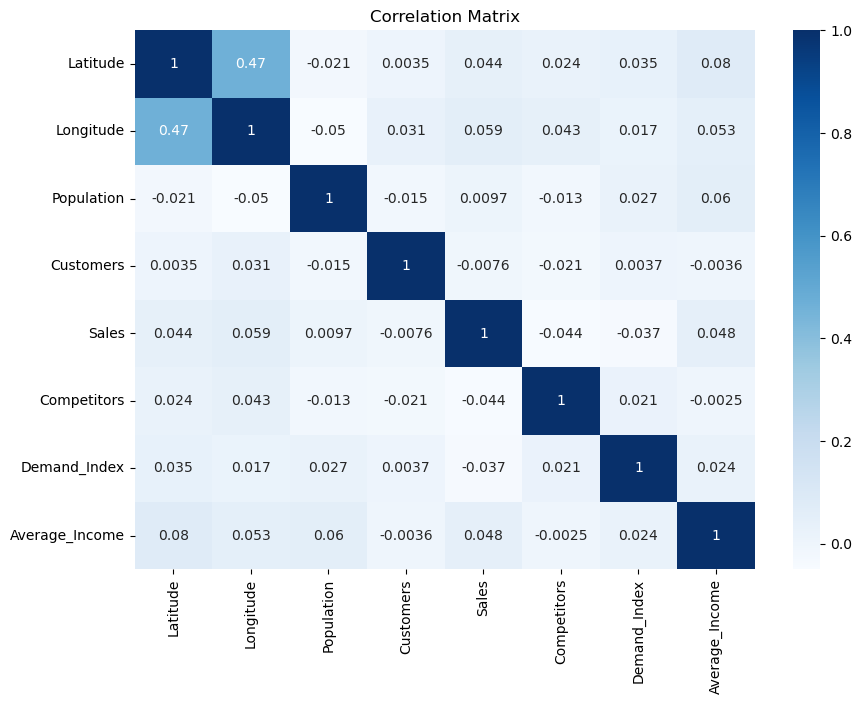

In [31]:
# Correlation Matrix
numeric_df = df.select_dtypes(include=["int64", "float64"])

corr = numeric_df.corr()

plt.figure(figsize=(10,7))
sns.heatmap(corr,
            annot=True,
            cmap="Blues")
plt.title("Correlation Matrix")
plt.show()


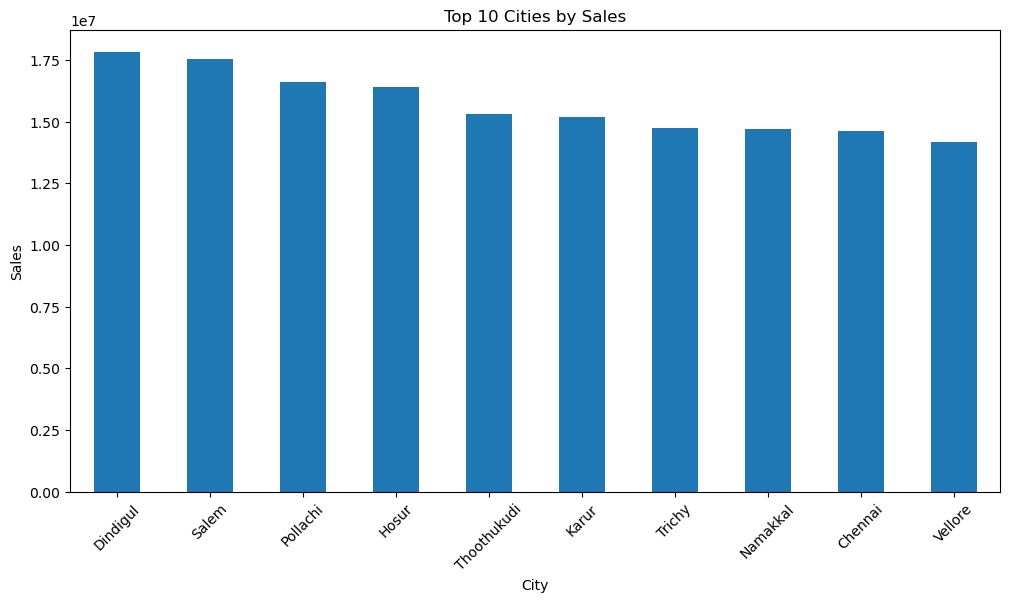

In [32]:
# Top Sales Cities Graph
plt.figure(figsize=(12,6))
city_sales.head(10).plot(kind="bar")

plt.title("Top 10 Cities by Sales")
plt.ylabel("Sales")
plt.xlabel("City")

plt.xticks(rotation=45)

plt.show()


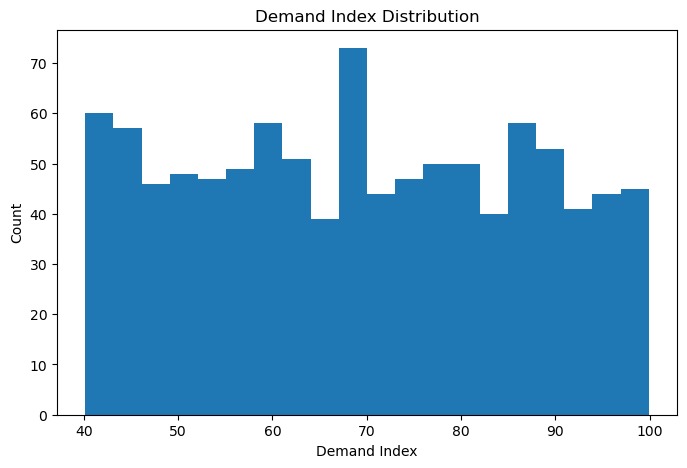

In [33]:
# Demand Distribution
plt.figure(figsize=(8,5))
plt.hist(df["Demand_Index"], bins=20)

plt.title("Demand Index Distribution")
plt.xlabel("Demand Index")
plt.ylabel("Count")

plt.show()

In [34]:
# =====================================================
# Phase 5 - Feature Engineering
# =====================================================

print("=" * 60)
print("PHASE 5 - FEATURE ENGINEERING")
print("=" * 60)

# Sales Per Customer
df["Sales_Per_Customer"] = (
    df["Sales"] /
    df["Customers"]
)

PHASE 5 - FEATURE ENGINEERING


In [35]:
# Competition Score
df["Competition_Score"] = (
    1 /
    (df["Competitors"] + 1)
)

In [37]:
# Expansion Score
df["Expansion_Score"] = (
    (df["Demand_Index"] * 0.40) +
    (df["Population"] / df["Population"].max() * 25) +
    (df["Competition_Score"] * 20) +
    (df["Average_Income"] / df["Average_Income"].max() * 15)
)

print("Expansion Score Created Successfully!")

display(df[["City", "Expansion_Score"]].head(10))

Expansion Score Created Successfully!


,City,Expansion_Score
0,Erode,61.773435
1,Hosur,73.016328
2,Salem,31.502721
3,Coimbatore,47.750747
4,Ooty,55.540835
5,Coimbatore,39.365743
6,Pollachi,35.741782
7,Dindigul,52.849398
8,Pollachi,40.594850
9,Thoothukudi,42.882769


In [38]:
# Recommended Expansion
df["Recommendation"] = np.where(

    (df["Existing_Store"] == "No") &
    (df["Expansion_Score"] > 55),

    "Recommended",

    "Not Recommended"

)

print("\nFeature Engineering Completed")



Feature Engineering Completed


In [39]:
display(df.head())

print("\nRecommendation Count")

print(df["Recommendation"].value_counts())

print("\nTop Expansion Opportunities")

display(

df.sort_values(
    "Expansion_Score",
    ascending=False
).head(10)

)

,City,Latitude,Longitude,Population,Customers,Sales,Competitors,Demand_Index,Average_Income,Existing_Store,Sales_Per_Customer,Competition_Score,Expansion_Score,Recommendation
0,Erode,11.316891,77.739871,2209218,4596,87866,12,87.17,41723,Yes,19.117929,0.076923,61.773435,Not Recommended
1,Hosur,12.773640,77.814919,2540000,3001,122714,4,90.68,69442,Yes,40.891036,0.200000,73.016328,Not Recommended
2,Salem,11.684402,78.177760,742375,3516,368388,14,49.97,23962,No,104.774744,0.066667,31.502721,Not Recommended
3,Coimbatore,11.044490,76.930425,2081632,1967,423531,5,56.71,26304,Yes,215.318251,0.166667,47.750747,Not Recommended
4,Ooty,11.442903,76.683334,1318772,2054,78404,8,89.10,40120,No,38.171373,0.111111,55.540835,Recommended



Recommendation Count
Recommendation
Not Recommended    792
Recommended        208
Name: count, dtype: int64

Top Expansion Opportunities


,City,Latitude,Longitude,Population,Customers,Sales,Competitors,Demand_Index,Average_Income,Existing_Store,Sales_Per_Customer,Competition_Score,Expansion_Score,Recommendation
881,Tirunelveli,8.693120,77.754284,2741712,1316,341107,3,98.35,82934,Yes,259.199848,0.250000,81.014453,Not Recommended
205,Erode,11.314240,77.733728,2574137,431,385151,1,95.09,60426,Yes,893.621810,0.500000,79.561933,Not Recommended
545,Karur,10.938730,78.049141,2724832,509,497876,4,93.70,89489,No,978.145383,0.200000,79.106441,Recommended
915,Pollachi,10.676016,77.043302,2155373,4034,290674,1,93.44,79563,No,72.056024,0.500000,78.601867,Recommended
320,Coimbatore,11.055123,76.949459,2959706,4745,158562,3,99.38,54218,Yes,33.416649,0.250000,78.456513,Not Recommended
638,Ooty,11.435761,76.706741,2799871,2495,175121,11,95.98,88762,No,70.188778,0.083333,78.189312,Recommended
370,Chennai,13.107555,80.306570,2974620,1854,322159,12,96.57,74219,Yes,173.764293,0.076923,77.329289,Not Recommended
499,Madurai,9.938179,78.137026,2416699,353,462182,2,97.41,62428,Yes,1309.297450,0.333333,76.178198,Not Recommended
871,Dindigul,10.379378,78.006261,2162605,609,131477,4,99.17,85768,Yes,215.889984,0.200000,75.988467,Not Recommended
875,Madurai,9.885789,78.121256,2702011,1384,279136,20,93.52,89948,Yes,201.687861,0.047619,75.873139,Not Recommended


In [40]:
# =====================================================
# Phase 6 - K-Means Clustering
# =====================================================

print("="*60)
print("PHASE 6 - K-MEANS CLUSTERING")
print("="*60)

# Features for clustering
features = df[[
    "Sales",
    "Population",
    "Demand_Index",
    "Competitors",
    "Average_Income"
]]


PHASE 6 - K-MEANS CLUSTERING


In [41]:
# Scale data
scaler = StandardScaler()

scaled_data = scaler.fit_transform(features)

In [42]:
# Train Model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(scaled_data)

cluster_names = {
    0:"High Potential",
    1:"Medium Potential",
    2:"Low Potential"
}


In [43]:
df["Cluster_Name"] = df["Cluster"].map(cluster_names)

print("\nCluster Distribution")

print(df["Cluster_Name"].value_counts())

display(df.head())



Cluster Distribution
Cluster_Name
Low Potential       371
High Potential      315
Medium Potential    314
Name: count, dtype: int64


,City,Latitude,Longitude,Population,Customers,Sales,Competitors,Demand_Index,Average_Income,Existing_Store,Sales_Per_Customer,Competition_Score,Expansion_Score,Recommendation,Cluster,Cluster_Name
0,Erode,11.316891,77.739871,2209218,4596,87866,12,87.17,41723,Yes,19.117929,0.076923,61.773435,Not Recommended,1,Medium Potential
1,Hosur,12.773640,77.814919,2540000,3001,122714,4,90.68,69442,Yes,40.891036,0.200000,73.016328,Not Recommended,0,High Potential
2,Salem,11.684402,78.177760,742375,3516,368388,14,49.97,23962,No,104.774744,0.066667,31.502721,Not Recommended,2,Low Potential
3,Coimbatore,11.044490,76.930425,2081632,1967,423531,5,56.71,26304,Yes,215.318251,0.166667,47.750747,Not Recommended,2,Low Potential
4,Ooty,11.442903,76.683334,1318772,2054,78404,8,89.10,40120,No,38.171373,0.111111,55.540835,Recommended,1,Medium Potential


In [44]:
# Cluster Centers

centers = pd.DataFrame(

scaler.inverse_transform(kmeans.cluster_centers_),

columns=features.columns

)

print("\nCluster Centers")

display(centers)


Cluster Centers


,Sales,Population,Demand_Index,Competitors,Average_Income
0,294564.695238,1.647330e+06,78.653270,5.346032,61178.587302
1,232459.152866,1.600398e+06,80.190573,15.742038,52306.044586
2,297387.132075,1.317555e+06,51.973154,10.894879,48933.787062


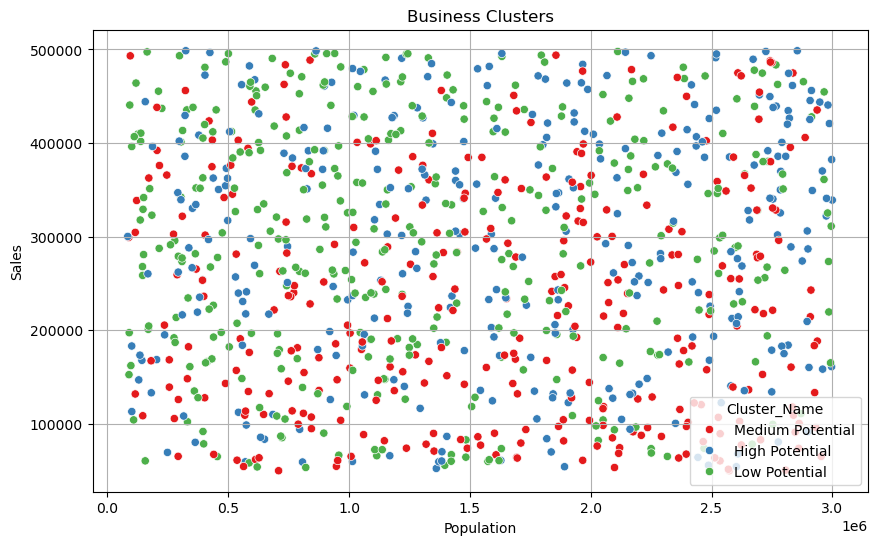

In [45]:
# Scatter Plot

plt.figure(figsize=(10,6))

sns.scatterplot(

data=df,

x="Population",

y="Sales",

hue="Cluster_Name",

palette="Set1"

)

plt.title("Business Clusters")

plt.xlabel("Population")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [46]:
# =====================================================
# Phase 7 - Interactive Geospatial Map
# =====================================================

print("="*60)
print("PHASE 7 - GEOSPATIAL VISUALIZATION")
print("="*60)


PHASE 7 - GEOSPATIAL VISUALIZATION


In [47]:
# Map Center

center_lat = df["Latitude"].mean()
center_lon = df["Longitude"].mean()

business_map = folium.Map(

location=[center_lat,center_lon],

zoom_start=7,

tiles="OpenStreetMap"

)

marker_cluster = MarkerCluster()

marker_cluster.add_to(business_map)


In [48]:
for index,row in df.iterrows():

    if row["Cluster_Name"]=="High Potential":
        color="green"

    elif row["Cluster_Name"]=="Medium Potential":
        color="orange"

    else:
        color="red"

    popup=f"""

<b>City :</b> {row['City']}<br>

<b>Sales :</b> {row['Sales']}<br>

<b>Population :</b> {row['Population']}<br>

<b>Demand :</b> {row['Demand_Index']}<br>

<b>Income :</b> {row['Average_Income']}<br>

<b>Cluster :</b> {row['Cluster_Name']}<br>

<b>Store :</b> {row['Existing_Store']}

"""

    folium.CircleMarker(

        location=[row["Latitude"],row["Longitude"]],

        radius=6,

        color=color,

        fill=True,

        fill_color=color,

        fill_opacity=0.8,

        popup=popup

    ).add_to(marker_cluster)

print("Markers Added Successfully")

Markers Added Successfully


In [49]:
# HeatMap

heat_data = [

[row["Latitude"],

row["Longitude"],

row["Sales"]]

for index,row in df.iterrows()

]

HeatMap(

heat_data,

radius=15,

blur=10

).add_to(business_map)

print("HeatMap Added")

HeatMap Added


In [50]:
business_map.save("geospatial_map.html")

print("="*60)

print("Interactive Map Saved Successfully")

print("File Name : geospatial_map.html")

print("="*60)

business_map

Interactive Map Saved Successfully
File Name : geospatial_map.html


In [51]:
# =====================================================
# PHASE 8 - BUSINESS EXPANSION RECOMMENDATION
# =====================================================

print("="*60)
print("PHASE 8 - BUSINESS EXPANSION RECOMMENDATION")
print("="*60)


PHASE 8 - BUSINESS EXPANSION RECOMMENDATION


In [52]:
# Recommendation Score
df["Recommendation_Score"] = (
    df["Demand_Index"] * 0.35 +
    (df["Sales"] / df["Sales"].max()) * 30 +
    (df["Population"] / df["Population"].max()) * 20 +
    (1 / (df["Competitors"] + 1)) * 15
)


In [53]:
# Business Decision
df["Expansion_Status"] = np.where(
    (df["Existing_Store"] == "No") &
    (df["Recommendation_Score"] >= 60),
    "Open New Store",
    "No Expansion"
)

recommendations = df[
    df["Expansion_Status"] == "Open New Store"
]

recommendations = recommendations.sort_values(
    "Recommendation_Score",
    ascending=False
)

print("\nTop Recommended Locations")

display(recommendations.head(10))

recommendations.to_csv(
    "expansion_recommendations.csv",
    index=False
)

print("\nRecommendation File Saved Successfully")


Top Recommended Locations


,City,Latitude,Longitude,Population,Customers,Sales,Competitors,Demand_Index,Average_Income,Existing_Store,Sales_Per_Customer,Competition_Score,Expansion_Score,Recommendation,Cluster,Cluster_Name,Recommendation_Score,Expansion_Status
545,Karur,10.938730,78.049141,2724832,509,497876,4,93.70,89489,No,978.145383,0.200000,79.106441,Recommended,0,High Potential,83.915804,Open New Store
445,Coimbatore,10.989309,76.975944,2854842,2582,498644,9,87.11,80582,No,193.123160,0.100000,74.069239,Recommended,0,High Potential,81.022332,Open New Store
828,Namakkal,11.228467,78.180479,2906813,4044,425257,4,88.29,36728,No,105.157517,0.200000,69.664239,Recommended,0,High Potential,78.866709,Open New Store
986,Sivakasi,9.415581,77.827501,2672036,4883,489552,7,84.54,81318,No,100.256400,0.125000,72.140384,Recommended,0,High Potential,78.732003,Open New Store
738,Pollachi,10.644152,77.011529,2834830,1783,461527,9,86.30,51605,No,258.848570,0.100000,68.748204,Recommended,0,High Potential,78.372360,Open New Store
961,Dindigul,10.390703,77.955253,2743541,245,486510,15,85.22,62757,No,1985.755102,0.062500,68.664339,Recommended,1,Medium Potential,78.326239,Open New Store
36,Coimbatore,11.034830,76.924807,2067264,1423,472113,4,93.87,83910,No,331.773015,0.200000,72.764162,Recommended,0,High Potential,78.041101,Open New Store
455,Pollachi,10.628963,77.042220,2517178,2333,491186,6,84.12,73886,No,210.538363,0.142857,69.800050,Recommended,0,High Potential,77.918672,Open New Store
444,Namakkal,11.227675,78.200608,2817210,3672,434648,7,87.79,72482,No,118.368192,0.125000,73.177397,Recommended,0,High Potential,77.534278,Open New Store
433,Karur,10.982318,78.105266,2490444,856,426221,9,94.93,57234,No,497.921729,0.100000,70.268336,Recommended,0,High Potential,76.972625,Open New Store



Recommendation File Saved Successfully


In [54]:
# =====================================================
# PHASE 9 - ADVANCED VISUALIZATION
# =====================================================

print("="*60)
print("PHASE 9 - VISUALIZATION")
print("="*60)


PHASE 9 - VISUALIZATION


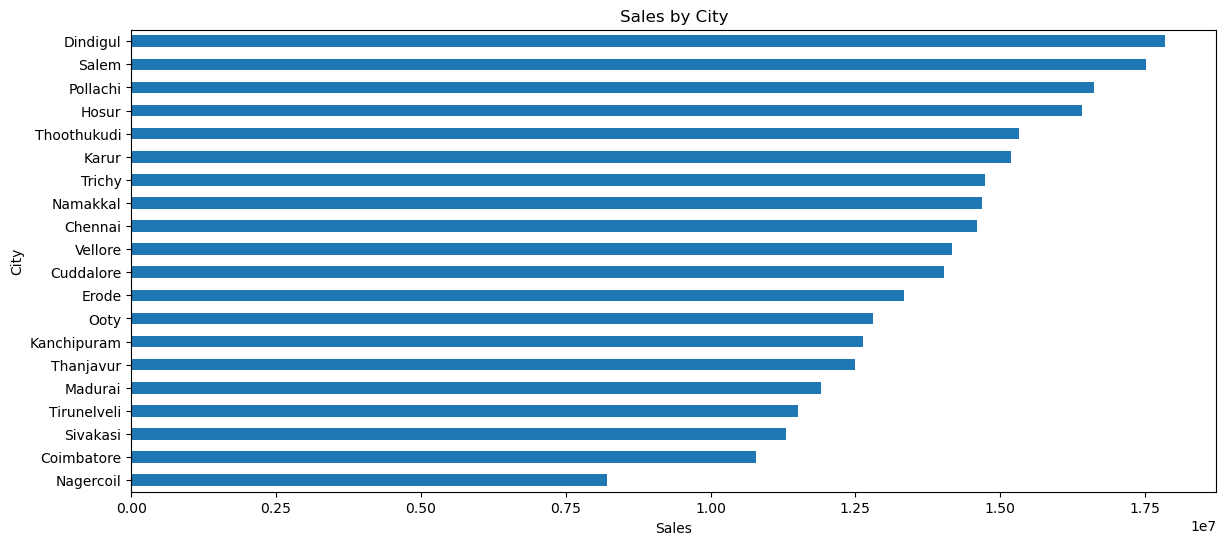

In [55]:
# Sales by City

plt.figure(figsize=(14,6))

city_sales = df.groupby("City")["Sales"].sum().sort_values()

city_sales.plot(kind="barh")

plt.title("Sales by City")

plt.xlabel("Sales")

plt.show()

